In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\pearl\OneDrive\Documents\sports-performance-analysis\sports-performance-analysis\data\sports_training_dataset.csv")
df.head()
df.info()
df.describe()
df.isnull().sum()
df['date'] = pd.to_datetime(df['Date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Athlete_ID         10 non-null     int64  
 1   Age                10 non-null     int64  
 2   Gender             10 non-null     object 
 3   Sport_Type         10 non-null     object 
 4   Session_ID         10 non-null     object 
 5   Date               10 non-null     object 
 6   Session_Duration   10 non-null     int64  
 7   Heart_Rate_Avg     10 non-null     int64  
 8   Speed_Avg          10 non-null     float64
 9   Distance_Covered   10 non-null     int64  
 10  Endurance_Score    10 non-null     float64
 11  Technique_Score    10 non-null     float64
 12  Performance_Level  10 non-null     object 
dtypes: float64(3), int64(5), object(5)
memory usage: 1.1+ KB


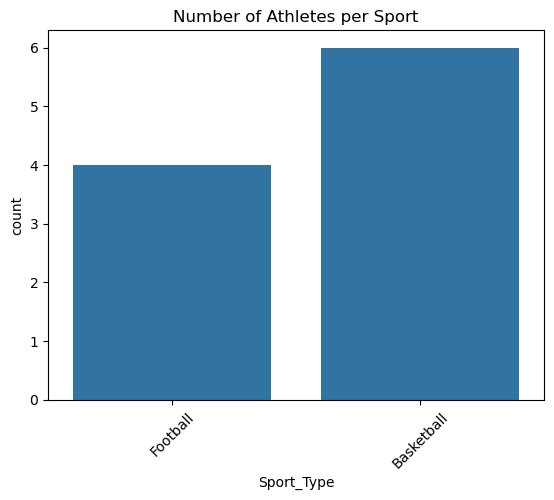

In [15]:
sns.countplot(data=df, x="Sport_Type")
plt.xticks(rotation=45)
plt.title("Number of Athletes per Sport")
plt.show()

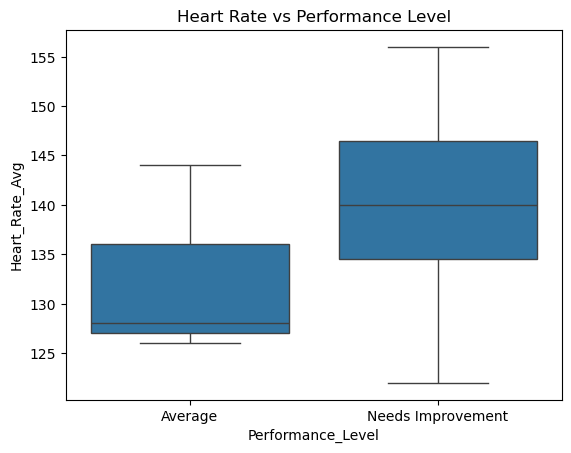

In [19]:
sns.boxplot(data=df, x="Performance_Level", y="Heart_Rate_Avg")
plt.title("Heart Rate vs Performance Level")
plt.show()

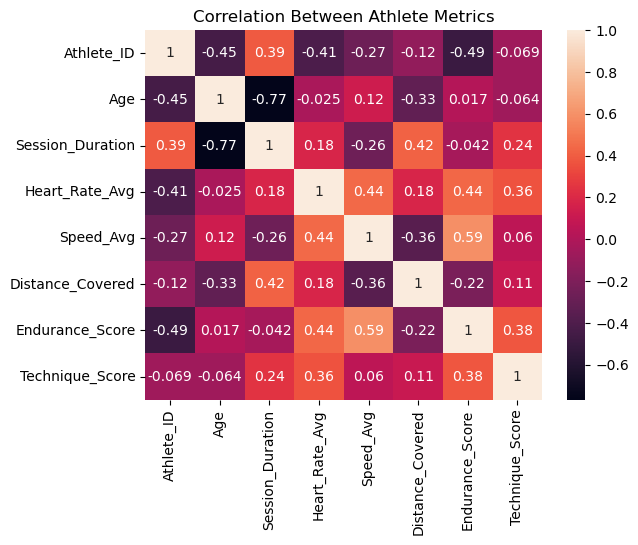

In [21]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Between Athlete Metrics")
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df[['Session_Duration','Heart_Rate_Avg','Speed_Avg','Distance_Covered','Endurance_Score','Technique_Score']]
y = df['Performance_Level']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.5
